# TP2 - Doublons et Standardisation

**Difficulté:** Débutant  
**Dataset:** customers_duplicates.csv  
**Description:** Détection et suppression des doublons, standardisation des formats

---


## Imports des Bibliothèques


In [262]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [263]:
# Charger le dataset
df = pd.read_csv('../data/customers_duplicates.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 12 lignes × 5 colonnes
Taille mémoire: 0.00 MB




,name,email,phone,gender,country
0,Bob Dubois,ALICE.MARTIN@GMAIL.COM,+33623456789,Male,Belgique
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR




<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   name     12 non-null     str  
 1   email    12 non-null     str  
 2   phone    12 non-null     str  
 3   gender   12 non-null     str  
 4   country  12 non-null     str  
dtypes: str(5)
memory usage: 612.0 bytes


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

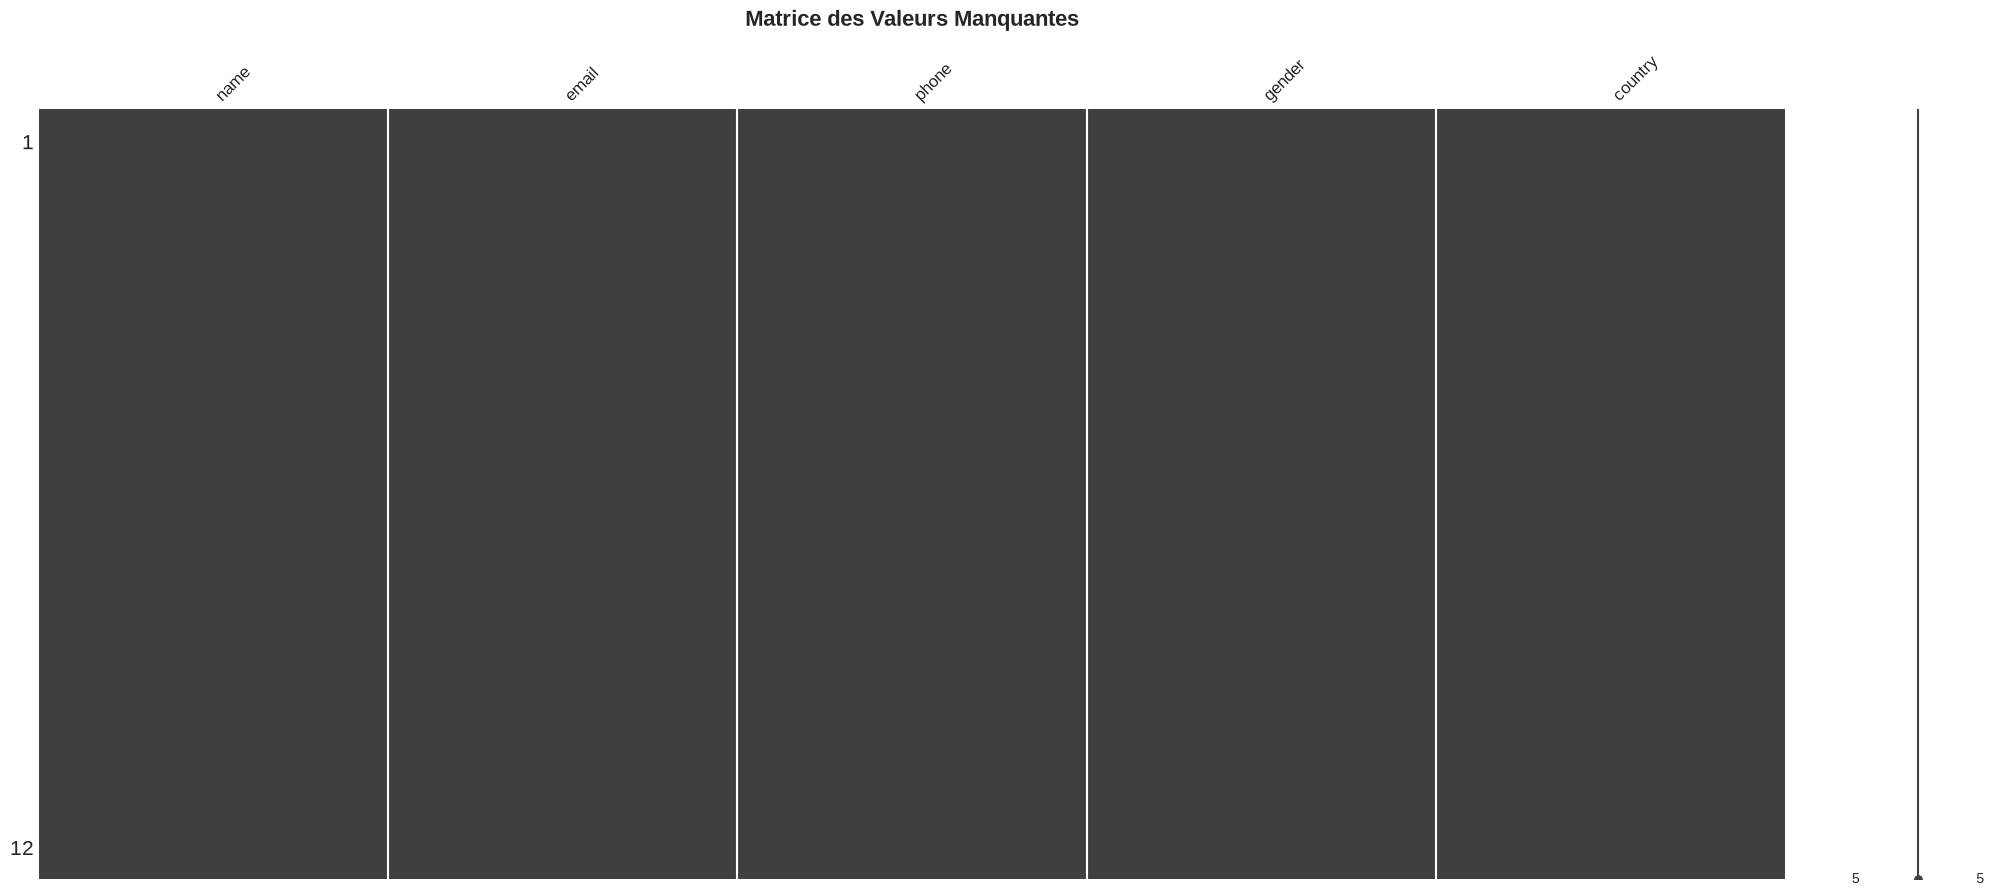


 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [264]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Combien de doublons exacts le dataset contient-il ?
2. Quelles colonnes peuvent servir de clés pour identifier les doublons ?
3. Y a-t-il des variations d'écriture dans les catégories (ex: 'M'/'Male') ?
4. Combien de formats de téléphone différents sont présents ?
5. Les emails sont-ils tous en minuscules ?
6. Y a-t-il des espaces en début ou fin de chaînes ?
7. Combien de clients uniques après déduplication ?
8. Quelle est la variation la plus fréquente du genre ?
9. Y a-t-il des doublons partiels (même nom mais email différent) ?
10. Quel pourcentage du dataset est constitué de doublons ?


In [265]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici


Réponses aux questions:


In [266]:
#1. Combien de doublons exacts le dataset contient-il ?

In [267]:
df.duplicated().sum()

np.int64(4)

In [268]:
#2. Quelles colonnes peuvent servir de clés pour identifier les doublons ?


In [269]:
#email + phone

In [270]:
#3. Y a-t-il des variations d'écriture dans les catégories (ex: 'M'/'Male') ?

In [271]:
df.value_counts()

name           email                      phone              gender  country 
Alice Martin   alice.martin@gmail.com     +33612345678       Female  France      3
David Bernard  david.bernard@company.com  +33645678901       Male    Suisse      2
Claire Petit   claire.petit@outlook.com   +33634567890       Female  France      2
Bob Dubois     ALICE.MARTIN@GMAIL.COM     +33623456789       Male    Belgique    1
alice martin   bob.dubois@yahoo.fr        +33623456789       Male    Belgique    1
Bob Dubois     bob.dubois@yahoo.fr        +33 6 12 34 56 78  Male    Belgique    1
David Bernard  david.bernard@company.com  +33645678901       F       Suisse      1
Claire Petit   claire.petit@outlook.com   +33634567890       Female  FR          1
Name: count, dtype: int64

In [272]:
#4. Combien de formats de téléphone différents sont présents ?

In [273]:
2

2

In [274]:
#5. Les emails sont-ils tous en minuscules ?

In [275]:
#6. Y a-t-il des espaces en début ou fin de chaînes ?

In [276]:
for i in df:
    df[i].str.contains(" ")

In [277]:
#7. Combien de clients uniques après déduplication ?

In [278]:
df.name.unique()

<StringArray>
['Bob Dubois', 'alice martin', 'David Bernard', 'Claire Petit',
 'Alice Martin']
Length: 5, dtype: str

In [279]:
#8. Quelle est la variation la plus fréquente du genre ?

In [280]:
df.gender.value_counts()

gender
Female    6
Male      5
F         1
Name: count, dtype: int64

In [281]:
#9. Y a-t-il des doublons partiels (même nom mais email différent) ?    

In [282]:
df[df.duplicated()]

,name,email,phone,gender,country
7,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
10,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
11,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France


In [283]:
#10. Quel pourcentage du dataset est constitué de doublons ?

In [284]:
df.duplicated().sum() * 100 / df.shape[0]

np.float64(33.333333333333336)

In [285]:
df.shape

(12, 5)

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Identifier et compter les doublons exacts
### Étape 2: Afficher quelques exemples de doublons
### Étape 3: Supprimer les doublons exacts en gardant la première occurrence
### Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
### Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
### Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
### Étape 7: Appliquer le mapping aux colonnes concernées
### Étape 8: Standardiser les formats de téléphone
### Étape 9: Vérifier les doublons restants après standardisation
### Étape 10: Créer un rapport de nettoyage avec les statistiques


In [286]:
# ========================================
# Étape 1: Identifier et compter les doublons exacts
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 1 complétée")

 Étape 1 complétée


In [287]:
df.duplicated().sum()

np.int64(4)

In [288]:
# ========================================
# Étape 2: Afficher quelques exemples de doublons
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 2 complétée")

 Étape 2 complétée


In [289]:
df[df.duplicated(keep=False)]

,name,email,phone,gender,country
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
7,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
10,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
11,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France


In [290]:
# ========================================
# Étape 3: Supprimer les doublons exacts en gardant la première occurrence
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 3 complétée")

 Étape 3 complétée


In [291]:
df_clean = df.drop_duplicates(keep="first")
df_clean

,name,email,phone,gender,country
0,Bob Dubois,ALICE.MARTIN@GMAIL.COM,+33623456789,Male,Belgique
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


In [292]:
# ========================================
# Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 4 complétée")

 Étape 4 complétée


In [293]:
# Standardisation de la casse et des espaces
def clean_email(text):
    if pd.isna(text):
        return text

    text = str(text)
    text = text.strip()
    text = text.lower()   # Pour les emails, identifiants
    text = ' '.join(text.split())
    
    # Standardiser la casse (selon le contexte)
    # text = text.lower()   # Pour les emails, identifiants
    # text = text.title()   # Pour les noms propres
    # text = text.upper()   # Pour les codes

    return text

# Application sur les colonnes textuelles
df_clean["email"] = df_clean["email"].apply(clean_email)
df_clean["email"]

0       alice.martin@gmail.com
1          bob.dubois@yahoo.fr
2          bob.dubois@yahoo.fr
3    david.bernard@company.com
4     claire.petit@outlook.com
5       alice.martin@gmail.com
6    david.bernard@company.com
8     claire.petit@outlook.com
Name: email, dtype: str

In [294]:
def clean_name(text):
    if pd.isna(text):
        return text

    text = str(text)
    text = text.strip()
    text = text.title()
    text = " ".join(text.split())
    
    return text

df_clean["name"] = df_clean["name"].apply(clean_name)
df_clean["name"]

0       Bob Dubois
1     Alice Martin
2       Bob Dubois
3    David Bernard
4     Claire Petit
5     Alice Martin
6    David Bernard
8     Claire Petit
Name: name, dtype: str

In [295]:
# ========================================
# Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 5 complétée")

 Étape 5 complétée


In [296]:
# Standardisation de la casse et des espaces
def clean_text(text):
    if pd.isna(text):
        return text

    text = str(text)
    text = text.strip()
    text = ' '.join(text.split())

    # Standardiser la casse (selon le contexte)
    # text = text.lower()   # Pour les emails, identifiants
    # text = text.title()   # Pour les noms propres
    # text = text.upper()   # Pour les codes

    return text

# Application sur les colonnes textuelles
text_columns = df_clean.select_dtypes(include=['object']).columns
for col in text_columns:
    df_clean[col] = df_clean[col].apply(clean_text)

df_clean

,name,email,phone,gender,country
0,Bob Dubois,alice.martin@gmail.com,+33623456789,Male,Belgique
1,Alice Martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


In [297]:
# ========================================
# Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 6 complétée")

 Étape 6 complétée


In [298]:

# Mapping des variations vers une valeur standard
category_mapping = {
    # Genre
    'M': 'Male', 'H': 'Male', 'Homme': 'Male', 'homme': 'Male',
    'F': 'Female', 'Femme': 'Female', 'femme': 'Female',
    # Pays
    'USA': 'United States', 'US': 'United States', 'Etats-Unis': 'United States',
    'UK': 'United Kingdom', 'GB': 'United Kingdom',
    "FR": "France"
}

In [299]:
# ========================================
# Étape 7: Appliquer le mapping aux colonnes concernées
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 7 complétée")

 Étape 7 complétée


In [300]:
# Application du mapping
for col in ['gender', 'country']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(lambda x: category_mapping.get(x, x))

df

,name,email,phone,gender,country
0,Bob Dubois,ALICE.MARTIN@GMAIL.COM,+33623456789,Male,Belgique
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
7,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


In [301]:
# ========================================
# Étape 8: Standardiser les formats de téléphone
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 8 complétée")

 Étape 8 complétée


In [302]:
import re

def standardize_phone(phone):
    if pd.isna(phone):
        return None

    phone = re.sub(r"\D", "", str(phone))

    if len(phone) == 10 and phone.startswith('0'):
        return f"+33{phone[1:]}"
    else:
        return f"+{phone}"
    

df_clean["phone"] = df_clean["phone"].apply(standardize_phone)
df_clean

,name,email,phone,gender,country
0,Bob Dubois,alice.martin@gmail.com,+33623456789,Male,Belgique
1,Alice Martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33612345678,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,Female,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


In [303]:
# ========================================
# Étape 9: Vérifier les doublons restants après standardisation
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 9 complétée")

 Étape 9 complétée


In [304]:
df[df.duplicated()]
df_clean = df_clean.drop_duplicates()
df_clean

,name,email,phone,gender,country
0,Bob Dubois,alice.martin@gmail.com,+33623456789,Male,Belgique
1,Alice Martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33612345678,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,Female,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse


In [308]:
df_clean = df_clean.sort_values(by="name").drop_duplicates(subset="name", keep="last")
df_clean

,name,email,phone,gender,country
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
2,Bob Dubois,bob.dubois@yahoo.fr,+33612345678,Male,Belgique
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse


In [306]:
# ========================================
# Étape 10: Créer un rapport de nettoyage avec les statistiques
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 10 complétée")

 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [313]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': df.shape[0] - df_clean.shape[0],
    'Colonnes_supprimées': df.shape[1] - df_clean.shape[1],
    'Valeurs_manquantes_traitées': df.isna().sum().sum() - df_clean.isna().sum().sum(),
    'Doublons_supprimés': df.duplicated().sum() - df_clean.duplicated().sum(),
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (12, 5)
Dimensions_finales...................... (4, 5)
Lignes_supprimées....................... 8
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 4
Outliers_traités........................ 0
Transformations_appliquées.............. []

 TP terminé avec succès!
